In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt

In [63]:
data = pd.read_excel('Когортный анализ.xlsx')
data.head()

,user_id,date,price
0,A0005,2020-03-25,50
1,A0005,2020-03-25,40
2,A0005,2020-03-26,70
3,A0005,2020-03-27,20
4,A0005,2020-03-29,50


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704840 entries, 0 to 704839
Data columns (total 3 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   user_id  704840 non-null  object        
 1   date     704840 non-null  datetime64[ns]
 2   price    704840 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 16.1+ MB


In [75]:
def get_month(x):
    return dt.datetime(x.year, x.month, 1)

In [76]:
data['month_year'] = data['date'].apply(get_month)
data.head()

,user_id,date,price,month_year
0,A0005,2020-03-25,50,2020-03-01
1,A0005,2020-03-25,40,2020-03-01
2,A0005,2020-03-26,70,2020-03-01
3,A0005,2020-03-27,20,2020-03-01
4,A0005,2020-03-29,50,2020-03-01


In [77]:
data['cohort_month'] = data.groupby('user_id')['month_year'].transform('min')
data

,user_id,date,price,month_year,cohort_month
0,A0005,2020-03-25,50,2020-03-01,2020-03-01
1,A0005,2020-03-25,40,2020-03-01,2020-03-01
2,A0005,2020-03-26,70,2020-03-01,2020-03-01
3,A0005,2020-03-27,20,2020-03-01,2020-03-01
4,A0005,2020-03-29,50,2020-03-01,2020-03-01
...,...,...,...,...,...
704835,Z9247,2021-01-10,20,2021-01-01,2021-01-01
704836,Z9247,2021-01-11,50,2021-01-01,2021-01-01
704837,Z9247,2021-01-11,70,2021-01-01,2021-01-01
704838,Z9247,2021-01-11,20,2021-01-01,2021-01-01


In [78]:
def get_date(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    day = df[column].dt.day
    return year, month, day

In [79]:
date_year, date_month, _ = get_date(data, 'date')
cohort_year, cohort_month, _ = get_date(data, 'cohort_month')

In [80]:
year_diff = date_year - cohort_year
month_diff = date_month - cohort_month

In [81]:
data['cohort_index'] = year_diff*12 + month_diff + 1

In [83]:
data.head()

,user_id,date,price,month_year,cohort_month,cohort_index
0,A0005,2020-03-25,50,2020-03-01,2020-03-01,1
1,A0005,2020-03-25,40,2020-03-01,2020-03-01,1
2,A0005,2020-03-26,70,2020-03-01,2020-03-01,1
3,A0005,2020-03-27,20,2020-03-01,2020-03-01,1
4,A0005,2020-03-29,50,2020-03-01,2020-03-01,1


In [108]:
grouped_users_cohort = data.groupby(['cohort_month', 'cohort_index']).agg(
    user_count=('user_id', 'nunique')
).reset_index()

grouped_users_cohort

,cohort_month,cohort_index,user_count
0,2020-01-01,1,1210
1,2020-01-01,2,455
2,2020-01-01,3,264
3,2020-01-01,4,247
4,2020-01-01,5,242
...,...,...,...
100,2020-12-01,2,805
101,2020-12-01,3,290
102,2021-01-01,1,2438
103,2021-01-01,2,738


In [127]:
data1 = grouped_users_cohort.pivot_table(index='cohort_month', 
                                         columns='cohort_index', 
                                         values='user_count')
data1

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14
cohort_month,,,,,,,,,,,,,,
2020-01-01,1210.0,455.0,264.0,247.0,242.0,207.0,185.0,172.0,165.0,171.0,164.0,159.0,162.0,149.0
2020-02-01,1111.0,440.0,222.0,202.0,201.0,171.0,133.0,123.0,113.0,90.0,94.0,76.0,62.0,NaN
2020-03-01,1545.0,527.0,306.0,290.0,286.0,250.0,223.0,208.0,186.0,187.0,182.0,175.0,NaN,NaN
2020-04-01,1333.0,515.0,238.0,219.0,228.0,186.0,144.0,143.0,136.0,125.0,111.0,NaN,NaN,NaN
2020-05-01,1738.0,581.0,313.0,301.0,302.0,260.0,240.0,235.0,219.0,206.0,NaN,NaN,NaN,NaN
2020-06-01,1480.0,558.0,265.0,247.0,249.0,216.0,186.0,174.0,153.0,NaN,NaN,NaN,NaN,NaN
2020-07-01,1995.0,649.0,332.0,312.0,293.0,256.0,243.0,224.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-01,1744.0,643.0,285.0,265.0,263.0,227.0,196.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,2081.0,701.0,336.0,312.0,303.0,266.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [128]:
first_column = data1.iloc[:, 0]

In [129]:
first_column

cohort_month
2020-01-01    1210.0
2020-02-01    1111.0
2020-03-01    1545.0
2020-04-01    1333.0
2020-05-01    1738.0
2020-06-01    1480.0
2020-07-01    1995.0
2020-08-01    1744.0
2020-09-01    2081.0
2020-10-01    1991.0
2020-11-01    2263.0
2020-12-01    2201.0
2021-01-01    2438.0
2021-02-01     371.0
Name: 1, dtype: float64

In [130]:
cohort_users = data1.div(first_column, axis=0).round(2)
cohort_users

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14
cohort_month,,,,,,,,,,,,,,
2020-01-01,1.0,0.38,0.22,0.20,0.20,0.17,0.15,0.14,0.14,0.14,0.14,0.13,0.13,0.12
2020-02-01,1.0,0.40,0.20,0.18,0.18,0.15,0.12,0.11,0.10,0.08,0.08,0.07,0.06,NaN
2020-03-01,1.0,0.34,0.20,0.19,0.19,0.16,0.14,0.13,0.12,0.12,0.12,0.11,NaN,NaN
2020-04-01,1.0,0.39,0.18,0.16,0.17,0.14,0.11,0.11,0.10,0.09,0.08,NaN,NaN,NaN
2020-05-01,1.0,0.33,0.18,0.17,0.17,0.15,0.14,0.14,0.13,0.12,NaN,NaN,NaN,NaN
2020-06-01,1.0,0.38,0.18,0.17,0.17,0.15,0.13,0.12,0.10,NaN,NaN,NaN,NaN,NaN
2020-07-01,1.0,0.33,0.17,0.16,0.15,0.13,0.12,0.11,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-01,1.0,0.37,0.16,0.15,0.15,0.13,0.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,1.0,0.34,0.16,0.15,0.15,0.13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


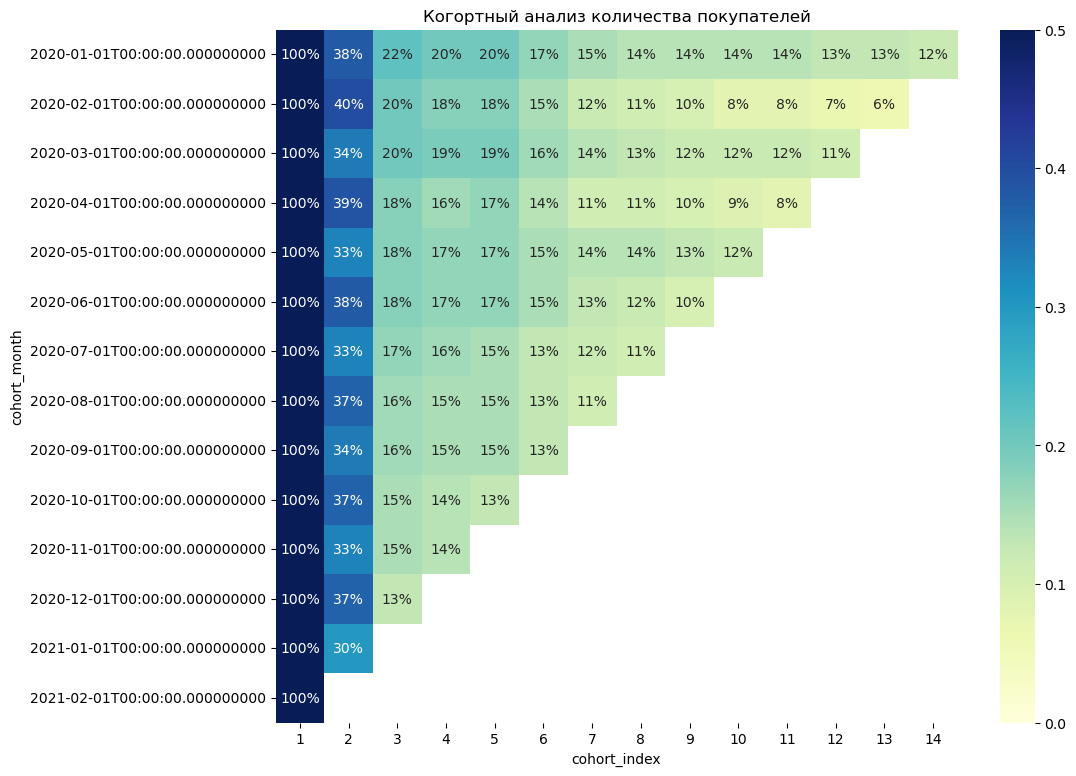

In [131]:
plt.figure(figsize=(11, 9))
plt.title('Когортный анализ количества покупателей')
sns.heatmap(data=cohort_users, 
            annot=True, 
            fmt='.0%', 
            vmin=0.0, 
            vmax=0.5, 
            cmap='YlGnBu')
plt.show()

In [132]:
cohort_grouped_total_revenue = data.groupby(['cohort_month', 'cohort_index']).agg(
    total_revenue=('price', 'sum')
).reset_index()
cohort_grouped_total_revenue

,cohort_month,cohort_index,total_revenue
0,2020-01-01,1,662180
1,2020-01-01,2,642990
2,2020-01-01,3,608410
3,2020-01-01,4,565650
4,2020-01-01,5,547080
...,...,...,...
100,2020-12-01,2,947310
101,2020-12-01,3,141740
102,2021-01-01,1,1319750
103,2021-01-01,2,268700


In [138]:
data2 = cohort_grouped_total_revenue.pivot_table(index='cohort_month', 
                                         columns='cohort_index', 
                                         values='total_revenue')
data2

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14
cohort_month,,,,,,,,,,,,,,
2020-01-01,662180.0,642990.0,608410.0,565650.0,547080.0,483840.0,455490.0,412040.0,407790.0,428040.0,382000.0,371740.0,360570.0,79310.0
2020-02-01,536310.0,594210.0,445590.0,450500.0,409640.0,366150.0,300350.0,278920.0,251840.0,212570.0,194800.0,156240.0,31080.0,NaN
2020-03-01,873000.0,797300.0,680220.0,666890.0,646610.0,546210.0,542030.0,486430.0,461720.0,465630.0,447040.0,90390.0,NaN,NaN
2020-04-01,648770.0,667480.0,526090.0,503450.0,482350.0,378620.0,354250.0,332740.0,329710.0,314460.0,61750.0,NaN,NaN,NaN
2020-05-01,992030.0,870090.0,737430.0,740850.0,699940.0,633220.0,584100.0,572410.0,568870.0,115380.0,NaN,NaN,NaN,NaN
2020-06-01,718980.0,759810.0,563430.0,559150.0,545300.0,472750.0,453890.0,411240.0,78310.0,NaN,NaN,NaN,NaN,NaN
2020-07-01,1106840.0,913300.0,739440.0,735260.0,661290.0,634590.0,604380.0,124890.0,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-01,844520.0,800350.0,607090.0,586730.0,603010.0,517030.0,94600.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,1164460.0,979070.0,784700.0,778600.0,710410.0,140880.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [140]:
first_column = data2.iloc[:, 0]
cohort_total_revenue = data2.div(first_column, axis=0)
cohort_total_revenue

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14
cohort_month,,,,,,,,,,,,,,
2020-01-01,1.0,0.971020,0.918799,0.854224,0.826180,0.730677,0.687864,0.622248,0.615830,0.646410,0.576882,0.561388,0.544520,0.119771
2020-02-01,1.0,1.107960,0.830844,0.839999,0.763812,0.682721,0.560031,0.520072,0.469579,0.396357,0.363223,0.291324,0.057952,NaN
2020-03-01,1.0,0.913288,0.779175,0.763906,0.740676,0.625670,0.620882,0.557194,0.528889,0.533368,0.512073,0.103540,NaN,NaN
2020-04-01,1.0,1.028839,0.810904,0.776007,0.743484,0.583597,0.546033,0.512878,0.508208,0.484702,0.095180,NaN,NaN,NaN
2020-05-01,1.0,0.877080,0.743355,0.746802,0.705563,0.638307,0.588793,0.577009,0.573440,0.116307,NaN,NaN,NaN,NaN
2020-06-01,1.0,1.056789,0.783652,0.777699,0.758436,0.657529,0.631297,0.571977,0.108918,NaN,NaN,NaN,NaN,NaN
2020-07-01,1.0,0.825142,0.668064,0.664288,0.597458,0.573335,0.546041,0.112835,NaN,NaN,NaN,NaN,NaN,NaN
2020-08-01,1.0,0.947698,0.718858,0.694750,0.714027,0.612218,0.112016,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020-09-01,1.0,0.840793,0.673875,0.668636,0.610077,0.120983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


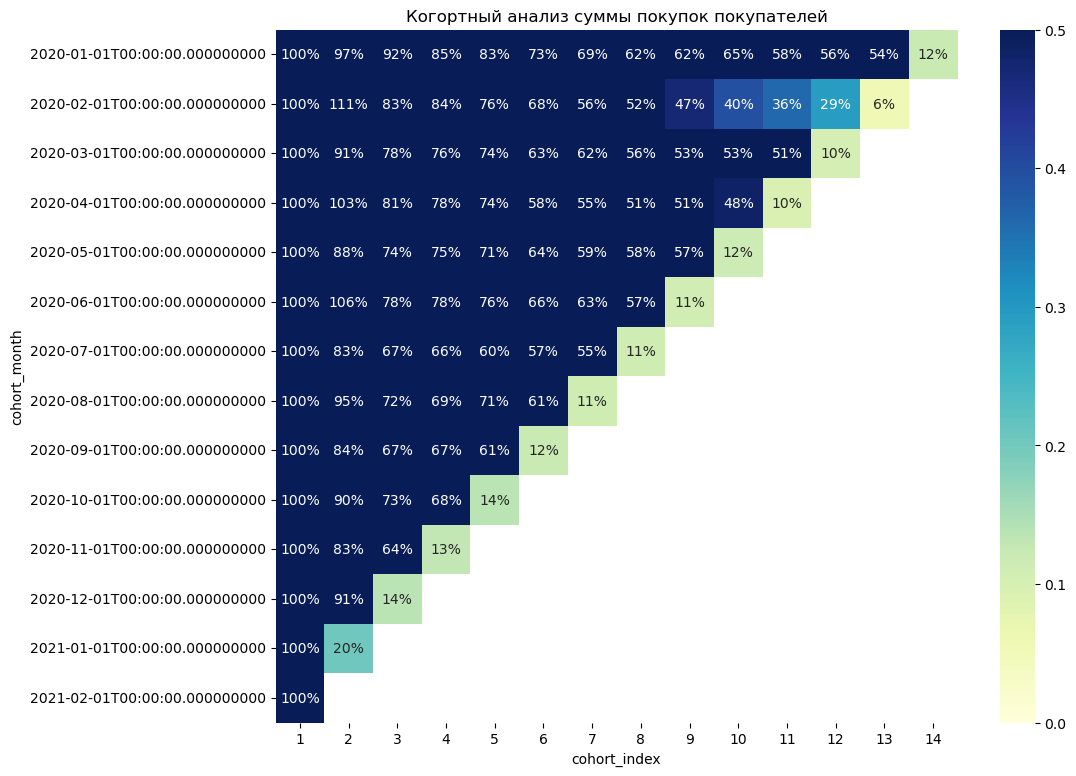

In [141]:
plt.figure(figsize=(11, 9))
plt.title('Когортный анализ суммы покупок покупателей')
sns.heatmap(data=cohort_total_revenue, 
            annot=True, 
            fmt='.0%', 
            vmin=0.0, 
            vmax=0.5, 
            cmap='YlGnBu')
plt.show()